# SpecModel tutorial

`SpecModel` turns a prepared atmosphere grid into a deterministic physical spectrum:

**atmosphere interpolation → rotation + radial-tangential macroturbulence + Gaussian instrumental broadening → relativistic RV shift → requested-wavelength sampling.**

This tutorial uses real **Coelho** grid spectra and an available **IRD order 8** sample. It demonstrates each stage, changes one parameter at a time, and compares with frozen jaxspec. Nothing is fitted. The model contains no observed flux, uncertainty, masks, continuum, likelihood or NumPyro inference.

**Requirements:** run from somewhere inside this `jaxstar` checkout, with the frozen `jaxspec` checkout next to it (`../jaxspec`), including its characterization grids and saved sample/reference outputs. Use a Python kernel with JAX, NumPy, SciPy, Matplotlib and IPython. Execution below uses float64 for a precise reference comparison. No download, external service, or writable access to `jaxspec` is required.

## 1. Load a prepared spectral library

First locate this checkout independently of whether the kernel starts in the repository root or in `docs/tutorials/specfit`. The small repository-only helpers are the same ones used by `dev_notebooks/specfit/specmodel_diagnostic.py`; they handle reference loading and repetitive plotting, not the model evaluations shown below.

In [1]:
from pathlib import Path
import copy
import os
import sys

repo_root = next(
    (p for p in (Path.cwd(), *Path.cwd().parents)
     if (p / "src/jaxstar/specfit/model.py").is_file()),
    None,
)
if repo_root is None:
    raise RuntimeError("Run this notebook from inside the jaxstar checkout")
reference_root = repo_root.parent / "jaxspec"
if not (reference_root / "characterization/reference_outputs/manifest.json").is_file():
    raise FileNotFoundError("Expected the frozen characterization data in ../jaxspec")

# All generated files stay in this ignored, repository-relative directory.
work_dir = repo_root / "examples/tutorials/.specmodel-data"
work_dir.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(work_dir / "matplotlib"))
sys.path.insert(0, str(repo_root / "src"))
sys.path.insert(0, str(repo_root / "dev_notebooks/specfit"))

import jax
import numpy as np
jax.config.update("jax_enable_x64", True)

%matplotlib inline
import matplotlib.pyplot as plt
from jaxstar.specfit import SpecModel, load_spectral_grid, save_spectral_grid, is_log_uniform
from _specmodel_reference import make_case, frozen_stages, verify_reference
from _specmodel_plotting import display_wavelength, plot_spectra, plot_comparison

print("Backend:", jax.default_backend())
print("Reference: ../jaxspec (read-only)")

Matplotlib is building the font cache; this may take a moment.


Backend: cpu
Reference: ../jaxspec (read-only)


The reference includes a legacy prepared Coelho NPZ, not the entire raw Coelho library. The existing reference helper extracts the atmosphere cell enclosing our example and converts its node spectra **offline** to log-uniform wavelength. It reproduces the frozen working samples for a meaningful comparison, including its historical endpoint trim.

This setup is performed once here, before any forward evaluation. The common artifact contains atmosphere axes, a flux payload, wavelengths, region identifiers and interpretation/provenance metadata. Subsequent runtime loading needs only that artifact. For your own data, replace this setup with `load_spectral_grid(your_prepared_path)`. Normal fitting-grid preparation uses an explicit `velocity_step`; it should not derive sampling from detector pixel count.

In [2]:
verify_reference(reference_root)  # Check the immutable source/sample hashes.
case = make_case(reference_root, work_dir, "coelho")
artifact = work_dir / "coelho_log.npz"
save_spectral_grid(artifact, case.spectra, overwrite=True)

# This is the source-library-agnostic runtime loading step.
library = load_spectral_grid(artifact)
print("Artifact:", artifact.relative_to(repo_root))
print("Library:", library.library, "| flux kind:", library.flux_kind)
print("Wavelength unit:", library.wavelength_unit, "| medium:", library.wavelength_medium)
print("Atmosphere axes:", library.grid.axis_names)
print("Region identifiers:", library.regions)

Artifact: examples/tutorials/.specmodel-data/coelho_log.npz
Library: coelho | flux kind: normalized
Wavelength unit: angstrom | medium: unknown
Atmosphere axes: ('teff', 'logg', 'feh', 'alpha')
Region identifiers: (8, 8)


## 2. Inspect wavelength regions and sampling

The flux field's leading dimensions are atmosphere axes. Its **payload** is `(region, pixel)`; wavelength is metadata with the same payload shape, not another atmosphere interpolation axis. One scalar atmosphere query produces every region at once.

A region can represent an echelle order or another wavelength segment. Here there are two rows for two observed intervals of **the same IRD order 8**. Both rows use the available order-8 model grid; these are not two independently observed orders. The legacy artifact labels the wavelength medium as `unknown`, so we retain its existing wavelength convention for both model and sample instead of guessing an air/vacuum conversion.

In [3]:
model_wave = np.asarray(library.wavelength)
n_region, n_model_pixel = model_wave.shape
field = library.grid.field("flux")
print("Library wavelength shape:", model_wave.shape)
print("Flux dimensions:", field.dims, "+", field.payload_dims)
print("Flux array shape:", field.values.shape)
for name in library.grid.axis_names:
    print(name, np.asarray(library.grid.axis(name)))

assert is_log_uniform(library)
dln = np.diff(np.log(model_wave), axis=1)
for i, region in enumerate(library.regions):
    print(f"row {i}, region {region}: {model_wave[i, 0]:.3f}–{model_wave[i, -1]:.3f} Å; "
          f"dv ≈ {299792.458 * dln[i].mean():.6f} km/s; "
          f"max spacing deviation = {np.max(np.abs(dln[i] - dln[i].mean())):.2e}")

Library wavelength shape: (2, 4998)
Flux dimensions: ('teff', 'logg', 'feh', 'alpha') + ('region', 'pixel')
Flux array shape: (2, 2, 2, 2, 2, 4998)
teff [5750. 6000.]
logg [4. 5.]
feh [-0.5  0. ]
alpha [0.  0.4]
row 0, region 8: 15239.046–15448.957 Å; dv ≈ 0.820756 km/s; max spacing deviation = 2.41e-15
row 1, region 8: 15239.046–15448.957 Å; dv ≈ 0.820756 km/s; max spacing deviation = 2.41e-15


A constant natural-log step corresponds to numerical velocity sampling `dv = 299792.458 × dlnlambda` in km/s. This is neither instrumental resolving power nor observed pixel spacing.

Choose requested wavelengths separately at evaluation time. The shared plotting helper makes a dense display grid spanning the real sample intervals so narrow features remain visible. This does **not** change the stored model sampling. Both input and output have `(n_region, n_pixel)` organization; a single-region model also accepts 1D input.

In [4]:
wav = display_wavelength(library.wavelength, case.wave)
print("Requested wavelength shape:", wav.shape)
for i, row in enumerate(wav):
    print(f"requested row {i}: {row[0]:.3f}–{row[-1]:.3f} Å")

Requested wavelength shape: (2, 5549)
requested row 0: 15248.410–15364.143 Å
requested row 1: 15368.846–15443.455 Å


## 3. Construct SpecModel

Construction checks that every region is log-uniform. Broadening uses this prepared grid directly, with no native-to-log interpolation inside a forward evaluation.

The default `vmax=50` km/s controls finite broadening-kernel support. The prepared regions must include enough wavelength margin for that support and the requested RV. Requests outside the safe coverage fail explicitly instead of extrapolating or clamping. Broader stars may need both wider prepared ranges and a larger support setting.

In [5]:
model = SpecModel(library)
print("Broadening support setting:", model.vmax, "km/s")

Broadening support setting: 50.0 km/s


## 4. Define stellar and instrumental parameters

- `atmosphere` supplies the named coordinates required by this Coelho grid.
- `vsini`, `vmacro`, `u1`, `u2` describe projected rotation, radial-tangential macroturbulence and quadratic limb darkening.
- `instrument.resolving_power` controls the Gaussian instrumental contribution.
- `rv` is the effective line-of-sight shift in km/s.

We start with one component; sections 13–14 extend the same model to SB2/SB3. Atmosphere coordinates must be **scalar**, inside the available axes. Post-interpolation parameters may be scalar (shared) or shape `(n_region,)`. We start with all scalar parameters, including RV and resolving power.

In [6]:
params = {
    "components": ({
        "atmosphere": {
            "teff": 5812.5,
            "logg": 4.2,
            "feh": -0.15,
            "alpha": 0.12,
        },
        "broadening": {
            "vsini": 6.3,
            "vmacro": 3.1,
            "u1": 0.5,
            "u2": 0.2,
        },
        "rv": 12.4,
    },),
    "instrument": {
        "resolving_power": 70000.0,
    },
}

## 5. Intrinsic, broadened, and full spectra

These are three wavelength-evaluated products, not merely internal diagnostics:

- **intrinsic:** atmosphere interpolation and sampling; no broadening or RV.
- **broadened:** the intrinsic spectrum with combined rotation, radial-tangential macroturbulence and Gaussian IP; no RV.
- **full:** the broadened spectrum with relativistic RV, then sampling.

Calling `model(params, wav)` is exactly the `full` method. All stages return physical flux without a continuum correction or dilution.

In [7]:
f_intrinsic = model.intrinsic(params, wav)
f_broadened = model.broadened(params, wav)
f_full = model.full(params, wav)
f_call = model(params, wav)

np.testing.assert_array_equal(f_call, f_full)
print("Intrinsic output shape:", f_intrinsic.shape)
print("Broadened output shape:", f_broadened.shape)
print("Full output shape:", f_full.shape)
print("model(params, wav) == model.full(params, wav): passed")

Intrinsic output shape: (2, 5549)
Broadened output shape: (2, 5549)
Full output shape: (2, 5549)
model(params, wav) == model.full(params, wav): passed


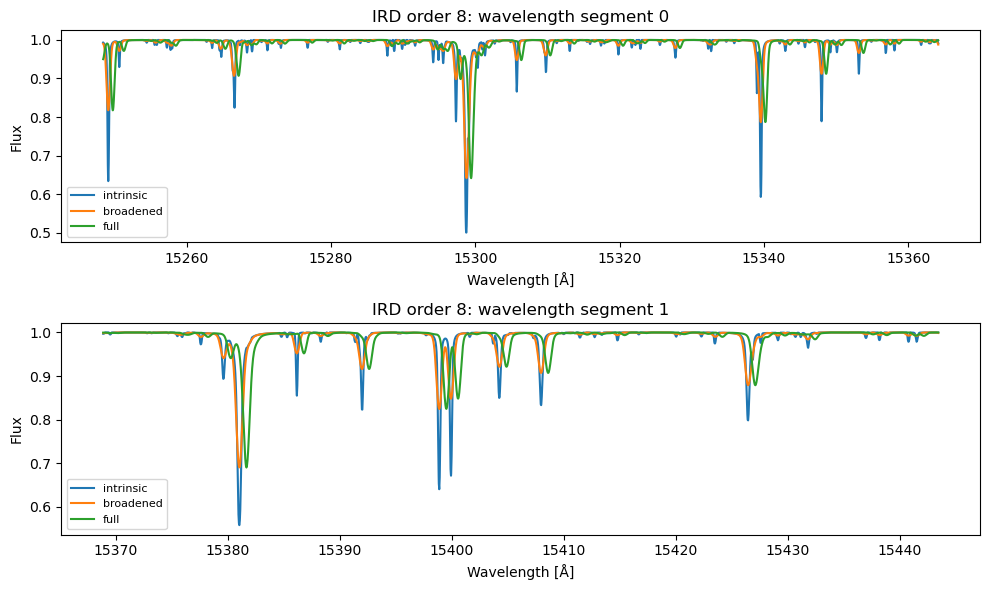

In [8]:
stages = {"intrinsic": f_intrinsic, "broadened": f_broadened, "full": f_full}
titles = [f"IRD order {region}: wavelength segment {i}" for i, region in enumerate(library.regions)]
plot_spectra(wav, stages, titles=titles)
plt.show()

The intrinsic features are sharper. Combined broadening spreads their absorption, and RV moves the broadened features redward. The same atmosphere is used in both rows.

## 6. Compare with a sample observation

The gray points below are the real, thinned observation snapshot saved by the frozen characterization workflow from `characterization/sample_data_ird.csv`. No observation is synthesized. **This is not a fit:** the representative physical parameters are fixed, and no continuum, noise model, masking or optimization is applied.

The displayed flux range emphasizes line profiles; sample values outside that range are not deleted or modified. Only the two available intervals of order 8 are shown.

Sample wavelength / flux shapes: (2, 62) (2, 62)


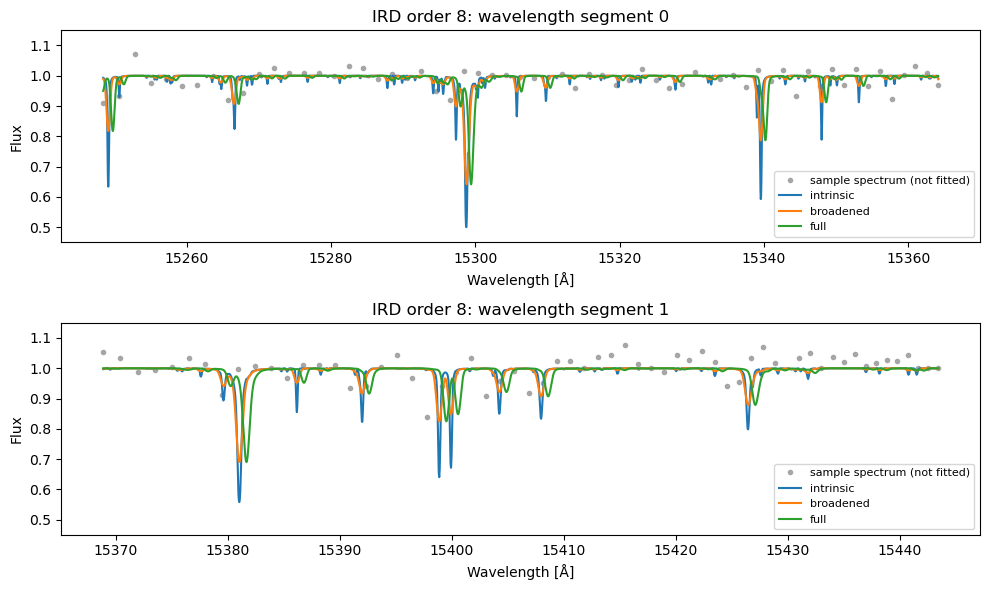

In [9]:
sample_wave = case.wave
sample_flux = case.oracle["flux_obs"]
print("Sample wavelength / flux shapes:", sample_wave.shape, sample_flux.shape)
plot_spectra(wav, stages, titles=titles,
             observation=(sample_wave, sample_flux), flux_limits=(0.45, 1.15))
plt.show()

## 7. Effect of projected rotation velocity

Use a closer view of a strong absorption feature. In the next three sections we evaluate `broadened`, so RV cannot obscure the broadening response. Each experiment changes just one scalar in a copy of the same parameter dictionary; only row 0 is displayed.

Larger `vsini` makes the rotational profile wider and typically shallower. A symmetric isolated line's centroid does not move; blends can change apparent minima.

Feature in row 0 near: 15298.725 Å


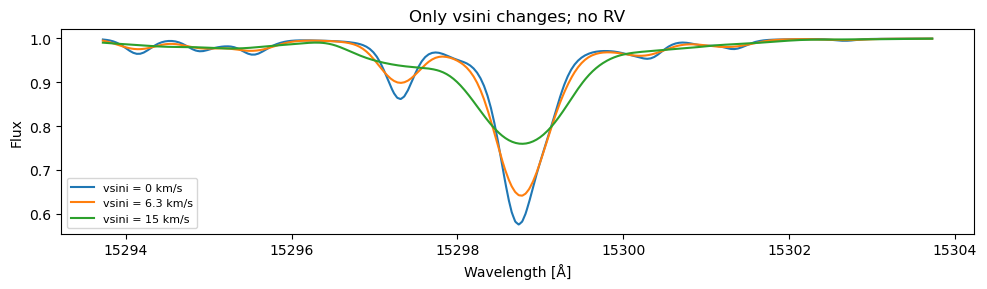

In [10]:
line_centers = [row[np.argmin(flux)] for row, flux in zip(wav, np.asarray(f_intrinsic))]
zoom_wave = np.stack([np.linspace(center - 5., center + 5., 1200) for center in line_centers])
print("Feature in row 0 near:", round(line_centers[0], 3), "Å")

rotation_curves = {}
for vsini in (0., 6.3, 15.):
    p = copy.deepcopy(params)
    p["components"][0]["broadening"]["vsini"] = vsini
    flux = model.broadened(p, zoom_wave)
    rotation_curves[f"vsini = {vsini:g} km/s"] = flux[:1]
plot_spectra(zoom_wave[:1], rotation_curves, titles=["Only vsini changes; no RV"])
plt.show()

## 8. Effect of macroturbulence

`vmacro` controls **radial-tangential macroturbulence**, a different physical broadening mechanism from rotation. Both spread spectral features, but their profiles need not have the same shape. Rotation, limb darkening and instrumental resolving power remain fixed here.

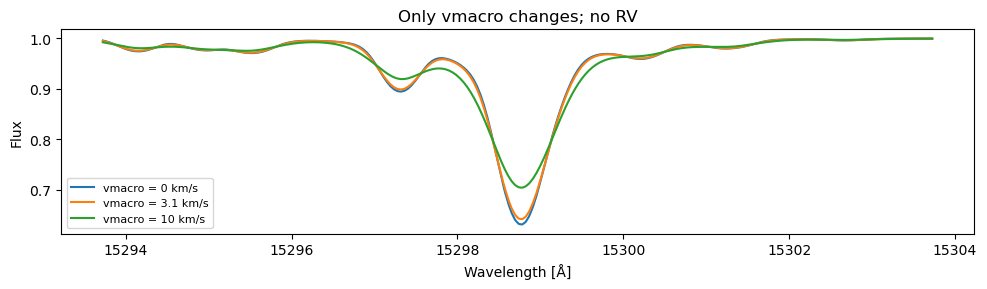

In [11]:
macro_curves = {}
for vmacro in (0., 3.1, 10.):
    p = copy.deepcopy(params)
    p["components"][0]["broadening"]["vmacro"] = vmacro
    flux = model.broadened(p, zoom_wave)
    macro_curves[f"vmacro = {vmacro:g} km/s"] = flux[:1]
plot_spectra(zoom_wave[:1], macro_curves, titles=["Only vmacro changes; no RV"])
plt.show()

## 9. Effect of instrumental resolving power

Lower resolving power gives a wider Gaussian instrumental profile. The default operator combines it efficiently with stellar broadening before applying the convolution. Its velocity standard deviation is `c / resolving_power / 2.354820`.

`resolving_power = np.inf` removes only the Gaussian instrumental contribution; rotation and macroturbulence remain. This resolving power is distinct from the model grid's numerical velocity sampling.

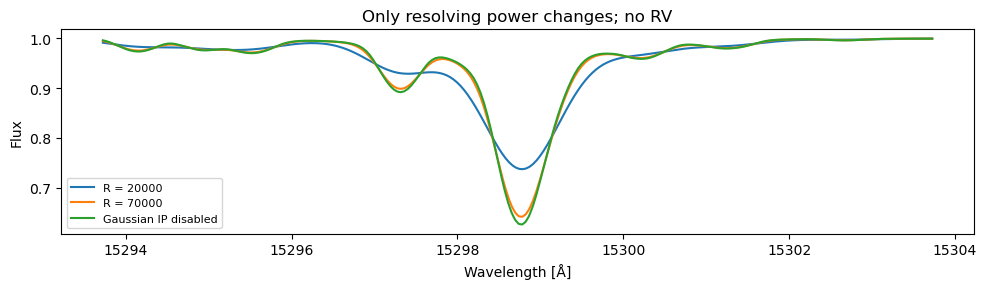

In [12]:
instrument_curves = {}
for resolving_power in (20000., 70000., np.inf):
    p = copy.deepcopy(params)
    p["instrument"]["resolving_power"] = resolving_power
    flux = model.broadened(p, zoom_wave)
    label = "Gaussian IP disabled" if np.isinf(resolving_power) else f"R = {resolving_power:g}"
    instrument_curves[label] = flux[:1]
plot_spectra(zoom_wave[:1], instrument_curves, titles=["Only resolving power changes; no RV"])
plt.show()

## 10. Effect of radial velocity

Now evaluate `full` and vary only RV. The model uses frozen jaxspec's relativistic convention:

`lambda_shifted = lambda × sqrt((1 + rv/c) / (1 - rv/c))`, with `c = 299792.458 km/s`.

Positive RV moves features redward. The same broadened profile is translated in log-wavelength; observed-grid interpolation can introduce small numerical differences.

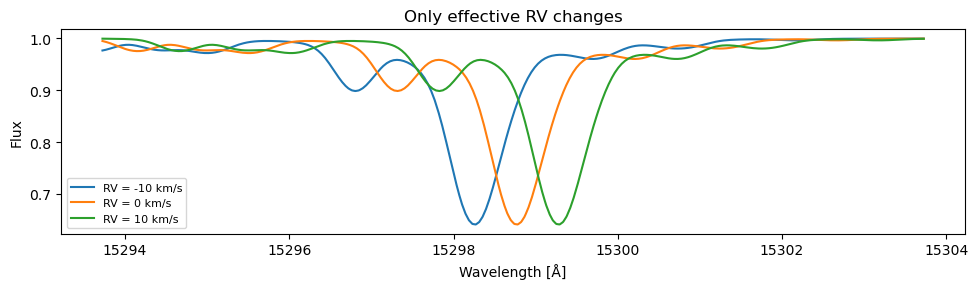

In [13]:
rv_curves = {}
for rv in (-10., 0., 10.):
    p = copy.deepcopy(params)
    p["components"][0]["rv"] = rv
    flux = model.full(p, zoom_wave)
    rv_curves[f"RV = {rv:g} km/s"] = flux[:1]
plot_spectra(zoom_wave[:1], rv_curves, titles=["Only effective RV changes"])
plt.show()

## 11. Region-specific parameters

A `(n_region,)` array maps directly to the stored row order, even when identifiers repeat. Here row 0 keeps the shared RV and row 1 gets a different RV. The atmosphere remains scalar and shared. This demonstrates a numerical capability, not a claim that these two intervals have different stellar RVs.

Constant arrays for all post-interpolation parameters are equivalent to their scalar forms.

RV array: [12.4 -7.2]
Row 0 unchanged; maximum row-1 change: 0.28941245922860936


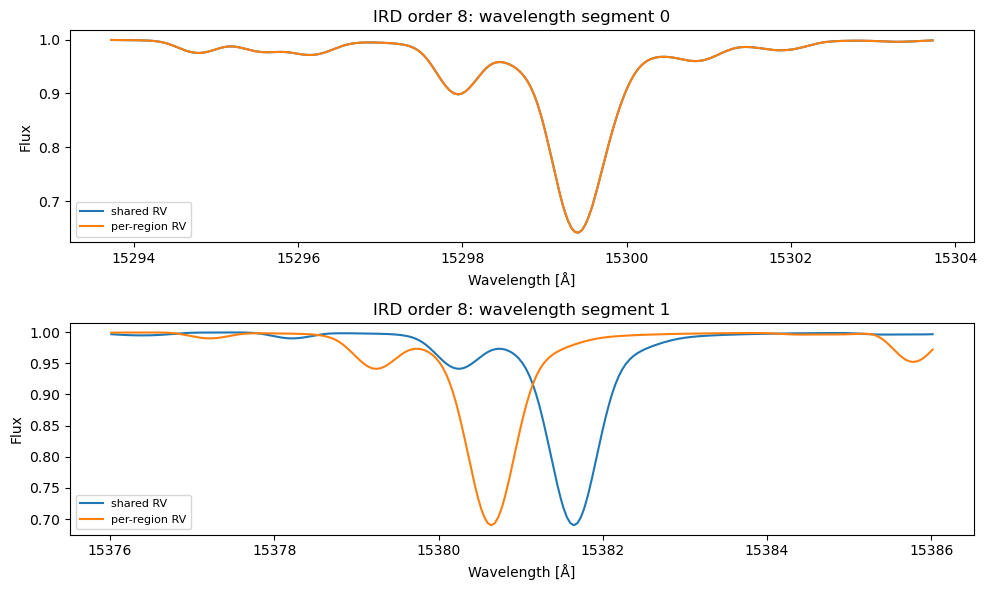

In [14]:
region_params = copy.deepcopy(params)
region_params["components"][0]["rv"] = np.array([12.4, -7.2])
f_region_rv = model.full(region_params, zoom_wave)
f_shared_rv = model.full(params, zoom_wave)
np.testing.assert_array_equal(f_region_rv[0], f_shared_rv[0])
print("RV array:", region_params["components"][0]["rv"])
print("Row 0 unchanged; maximum row-1 change:", float(np.max(np.abs(f_region_rv[1] - f_shared_rv[1]))))
plot_spectra(zoom_wave, {"shared RV": f_shared_rv, "per-region RV": f_region_rv}, titles=titles)
plt.show()

In [15]:
constant_params = copy.deepcopy(params)
for name, value in params["components"][0]["broadening"].items():
    constant_params["components"][0]["broadening"][name] = np.full(n_region, value)
constant_params["components"][0]["rv"] = np.full(n_region, params["components"][0]["rv"])
constant_params["instrument"]["resolving_power"] = np.full(n_region, params["instrument"]["resolving_power"])
f_constant = model.full(constant_params, wav)
np.testing.assert_array_equal(f_constant, f_full)
print("Scalar vs constant per-region arrays: passed")

Scalar vs constant per-region arrays: passed


## 12. Comparison with frozen jaxspec

The existing reference helper evaluates the hash-checked, frozen physical routines using **the same parameters and compatible model wavelengths**. It reads source without importing the sibling package or writing bytecode/reference outputs there. This comparison does not add legacy continuum or dilution.

Old jaxspec interpolated an atmosphere spectrum onto its internal log grid at runtime. Here node spectra were resampled offline, before atmosphere interpolation. Those operations commute mathematically under linear interpolation but may accumulate floating-point rounding differently. Compare on the safe interior; legacy endpoint clamping and zero-padded edges are deliberately excluded.

Full spectrum maximum absolute difference: 9.575e-10
intrinsic : max |new - frozen| = 3.910e-09
broadened : max |new - frozen| = 9.561e-10
full      : max |new - frozen| = 9.575e-10


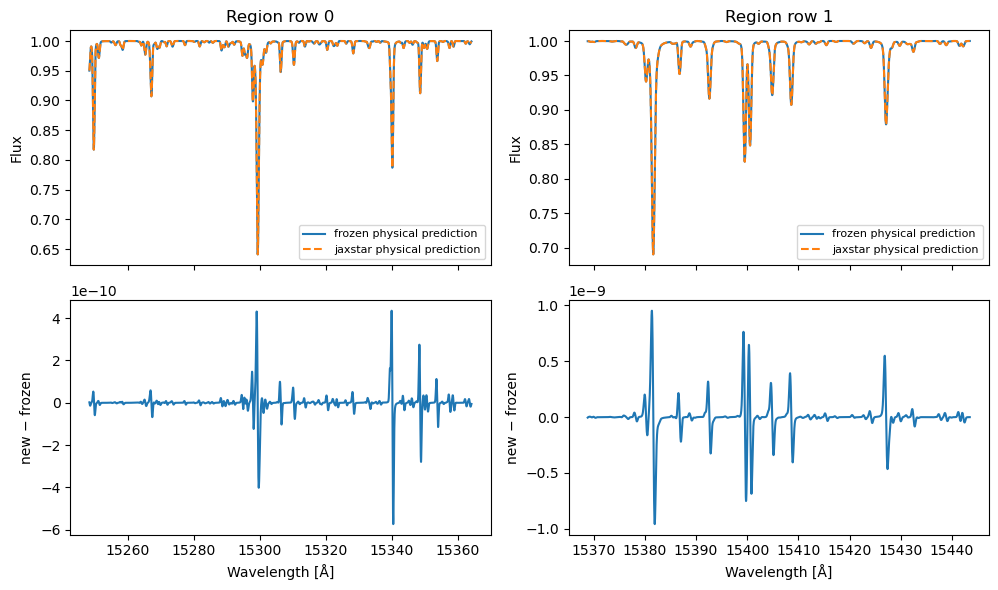

In [16]:
frozen = frozen_stages(case, params, wav)
f_frozen = np.asarray(frozen["full"])
difference = np.asarray(f_full) - f_frozen
max_difference = float(np.max(np.abs(difference)))
print(f"Full spectrum maximum absolute difference: {max_difference:.3e}")
for name, current in stages.items():
    expected = np.asarray(frozen[name])
    np.testing.assert_allclose(current, expected, rtol=5e-6, atol=1e-6)
    print(f"{name:10s}: max |new - frozen| = {np.max(np.abs(np.asarray(current) - expected)):.3e}")
plot_comparison(wav, f_frozen, np.asarray(f_full))
plt.show()

## 13. SB2: relative stellar fluxes and total-light dilution

One `SpecModel` evaluates every component through the same physical path and library. The following binary is a **parameter illustration**, not a fit to the IRD observation above.

`flux_weights` are nonnegative relative stellar continuum fluxes; they need not sum to one. Their normalized stellar-only fractions are `q = a / sum(a)`. `dilution = d` retains the single-star definition: featureless `F_dil / F_total`, with `0 <= d < 1`. Actual stellar fractions of total light are `w = (1-d)q`. Thus `total = d + sum(w_i * f_i)`; overall rescaling of all stellar weights changes nothing.

The normal call returns only the total spectrum. `decompose` returns raw components, weighted stellar contributions and both kinds of fractions. Its arrays retain the region axis, even with single-region 1D wavelength input. `stage="intrinsic"` or `stage="broadened"` also exposes those component stacks; the default is `"full"`.

In [17]:
primary = copy.deepcopy(params["components"][0])
secondary = copy.deepcopy(primary)
secondary["atmosphere"].update(teff=5900., logg=4.35, feh=-0.25, alpha=0.20)
secondary["broadening"].update(vsini=9., vmacro=4., u1=0.4, u2=0.25)
secondary["rv"] = -12.

sb2 = {
    "components": (primary, secondary),
    "flux_weights": (1.0, 0.25),
    "dilution": 0.1,
    "instrument": copy.deepcopy(params["instrument"]),
}
total2 = model(sb2, zoom_wave)
parts2 = model.decompose(sb2, zoom_wave)
np.testing.assert_allclose(total2, parts2.total)
np.testing.assert_allclose(parts2.total, parts2.dilution[:, None] + parts2.weighted_components.sum(axis=0))
np.testing.assert_allclose(parts2.stellar_fractions.sum(axis=0), 1.)
np.testing.assert_allclose(parts2.light_fractions.sum(axis=0) + parts2.dilution, 1.)
print("Stellar-only q (component × region):", np.asarray(parts2.stellar_fractions))
print("Total-light stellar w:", np.asarray(parts2.light_fractions))
print("Dilution:", np.asarray(parts2.dilution))
print("Component stack:", parts2.components.shape)

Stellar-only q (component × region): [[0.8 0.8]
 [0.2 0.2]]
Total-light stellar w: [[0.72 0.72]
 [0.18 0.18]]
Dilution: [0.1 0.1]
Component stack: (2, 2, 1200)


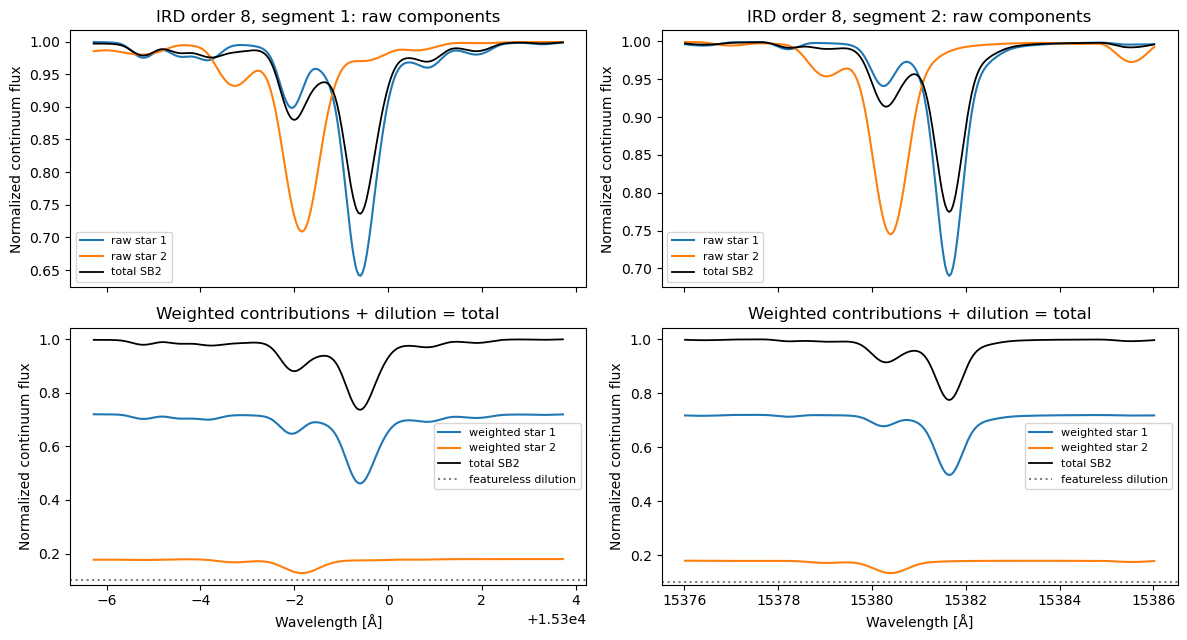

In [18]:
fig, axes = plt.subplots(2, len(zoom_wave), figsize=(12, 6.5), squeeze=False, sharex="col")
for region in range(len(zoom_wave)):
    for component in range(2):
        axes[0, region].plot(zoom_wave[region], parts2.components[component, region], label=f"raw star {component + 1}")
        axes[1, region].plot(zoom_wave[region], parts2.weighted_components[component, region], label=f"weighted star {component + 1}")
    for row in range(2):
        axes[row, region].plot(zoom_wave[region], total2[region], color="black", lw=1.3, label="total SB2")
        axes[row, region].legend(fontsize=8)
        axes[row, region].set_ylabel("Normalized continuum flux")
    axes[1, region].axhline(float(parts2.dilution[region]), color="gray", ls=":", label="featureless dilution")
    axes[1, region].legend(fontsize=8)
    axes[1, region].set_xlabel("Wavelength [Å]")
    axes[0, region].set_title(f"IRD order 8, segment {region + 1}: raw components")
    axes[1, region].set_title("Weighted contributions + dilution = total")
fig.tight_layout()
plt.show()

## 14. SB3 and region-dependent flux ratios

Adding a third entry uses the same component physics, without another model class. Atmosphere parameters stay scalar per star. Broadening and RV may be scalar or `(n_region,)`. The shared instrumental resolving power may also be scalar or per region.

Weights may be `(N,)` or `(N, n_region)`; a tuple can mix scalar and per-region entries. Dilution is scalar or per region. Neither varies pixel by pixel inside a region. Multiple components require explicit weights; a lone star defaults to weight one and dilution zero. Invalid negative/nonfinite weights, all-zero stellar light in any region, and invalid dilution fail clearly. Under JIT the tuple length and optional decomposition stage are static, while all numerical values remain dynamic.

SB3 components: (3, 2, 1200)
Stellar-only q: [[0.72992701 0.625     ]
 [0.18248175 0.25      ]
 [0.08759124 0.125     ]]
Total-light stellar w: [[0.69343066 0.5625    ]
 [0.17335766 0.225     ]
 [0.08321168 0.1125    ]]


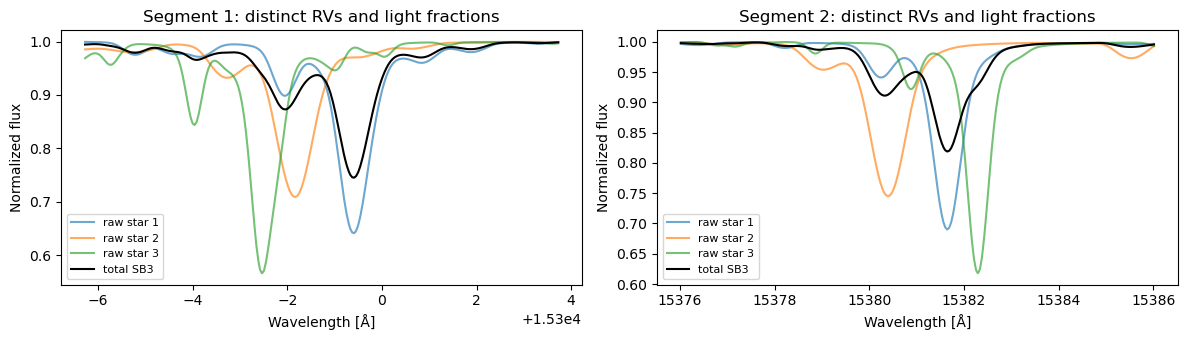

In [19]:
third = copy.deepcopy(primary)
third["atmosphere"].update(teff=5780., logg=4.1, feh=-0.05, alpha=0.05)
third["broadening"].update(vsini=3., vmacro=2., u1=0.6, u2=0.1)
third["rv"] = np.array([-25., 25.])
sb3 = {
    "components": (primary, secondary, third),
    "flux_weights": np.array([[1., 1.], [0.25, 0.4], [0.12, 0.2]]),
    "dilution": np.array([0.05, 0.1]),
    "instrument": copy.deepcopy(params["instrument"]),
}
total3 = model(sb3, zoom_wave)
parts3 = model.decompose(sb3, zoom_wave)
np.testing.assert_allclose(total3, parts3.total)
print("SB3 components:", parts3.components.shape)
print("Stellar-only q:", np.asarray(parts3.stellar_fractions))
print("Total-light stellar w:", np.asarray(parts3.light_fractions))

fig, axes = plt.subplots(1, len(zoom_wave), figsize=(12, 3.5), squeeze=False)
for region, ax in enumerate(axes[0]):
    for component in range(3):
        ax.plot(zoom_wave[region], parts3.components[component, region], alpha=0.65, label=f"raw star {component + 1}")
    ax.plot(zoom_wave[region], total3[region], color="black", lw=1.5, label="total SB3")
    ax.set(xlabel="Wavelength [Å]", ylabel="Normalized flux", title=f"Segment {region + 1}: distinct RVs and light fractions")
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## Reproducibility and next use

The plots above are inline outputs; no PNG files or ephemeral output paths are needed. Preparation writes only `examples/tutorials/.specmodel-data/` (ignored by Git), which can be recreated by rerunning this notebook. The executed outputs record this representative run, including shapes and numerical differences.

The tutorial requires the sibling **frozen characterization data** for its real sample and legacy comparison; those files are not bundled in `jaxstar` and are never modified. If the sibling checkout is elsewhere, change `reference_root` in the first cell. Once you have your own common prepared artifact, constructing and evaluating `SpecModel` does not require any raw/reference library.

`dev_notebooks/specfit/specmodel_diagnostic.py` remains the non-interactive batch alternative for Coelho, BOSZ and TLUSTY, parameter overrides, metrics and optional figure files. It shares the small plotting and read-only reference helpers with this notebook. The tutorial introduces no new physics or public API and performs no fitting, continuum calculation, likelihood evaluation, inference or probabilistic modeling. The SB2/SB3 sections illustrate deterministic composition only.